
## Spectral Gamma Ray Clustering using Self Organizing Maps (SOM)

#### Ameena AlJehairan
#### Department of Geological Sciences, Jackson School of Geosciences

### Subsurface Machine Learning Course, The University of Texas at Austin
#### Hildebrand Department of Petroleum and Geosystems Engineering, Cockrell School of Engineering


_____________________

Workflow supervision and review by:

#### Instructor: Prof. Michael Pyrcz, Ph.D., P.Eng., Associate Professor, The Univeristy of Texas at Austin
[Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Geostatistics Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [Applied Geostats in Python e-book](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) | [Applied Machine Learning in Python e-book](https://geostatsguy.github.io/MachineLearningDemos_Book/) | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)

#### Course TA: Maria Fernanda Gonzalez, Graduate Student, The University of Texas at Austin


### Executive Summary
This project investigates how unsupervised learning can reveal geologically meaningful structure in spectral gamma-ray data obtained from the Utah FORGE well. Four standardized spectral components: potassium (HFK), thorium (HTHO), uranium (HURA), and computed gamma ray (HCGR) were used to train a 10×10 Self Organizing Map (SOM), followed by hierarchical clustering to group similar geochemical responses. The model recovered distinct geochemical clusters corresponding to K-, Th-, and U-dominant signatures, demonstrating that SOMs can capture latent lithologic patterns without labels. These results support the effectiveness of unsupervised learning for classification projects. 

### What are Self Organizing Maps (SOM)?
Self Organizing Maps (SOM) are an unsupervised neural-network algorithm used to project high dimensional data onto a lower dimensional grid while preserving the topological structure of the dataset. During training, each node on the map competes to represent the input data, and the “winning” node and its neighbors are updated to become more similar to the input. Over many iterations, the SOM organizes itself so that similar data points map to nearby nodes, and dissimilar points map farther apart. This makes SOM a powerful tool used for pattern discovery, clustering, and visualization in multivariate datasets.

### Import Packages

In [242]:
#load and organize data
import lasio                     #load .LAS files
import pandas as pd              #organize and manipulate tabular data
import numpy as np               #numerical operations

#standardize features
from sklearn.preprocessing import StandardScaler   #standardizing features before SOM training

#visualization and plotting
import matplotlib.pyplot as plt  #generate plots
import seaborn as sns            #enhance plot quality (pairplots, countplots)

#SOM training
from minisom import MiniSom      #build and train Self Organizing Map (SOM)

#hierarchical clustering
from sklearn.cluster import AgglomerativeClustering   #clustering SOM neuron weights

#PCA projection
from sklearn.decomposition import PCA

#cluster validation
from sklearn.metrics import silhouette_score   #quality index (silhouette)

### Functions

#### Data Handling (Pandas / NumPy)
- `values`, `astype()`, `iloc[]`, `copy()`, `value_counts()`
- `array()`, `reshape()`, `shape`

#### Self Organizing Map (MiniSom)
- `MiniSom()`
- `random_weights_init()`
- `train_random()`
- `winner()`
- `distance_map()`
- `quantization_error()`
- `get_weights()`

#### Clustering & Dimensionality Reduction (Scikit-Learn)
- `AgglomerativeClustering()`, `fit_predict()`
- `PCA()`, `fit_transform()`
- `silhouette_score()`

#### Visualization (Matplotlib/Seaborn)
- `figure()`, `scatter()`, `pcolor()`, `colorbar()`
- `title()`, `xlabel()`, `ylabel()`, `invert_yaxis()`, `show()`
- `pairplot()`, `countplot()`

### Load Data

- The dataset `UnivUtah_Forge-16A-78-32_Spectral.las` contains spectral GR well logs from the Utah FORGE project
- Key features I will be working on are the spectral components of gamma radiation: potassium (HFK), thorium (HTHO), and uranium (HURA) logs
- The data is **standardized to mean = 0 and variance = 1,** to ensures consistent scaling across all input variables for the SOM algorithm


In [243]:
#Pyrcz, M.J., 2024, Applied Machine Learning in Python: A Hands-on Guide with Code [e-book]. Zenodo. DOI: 10.5281/zenodo.15169138 
#Pyrcz, M.J., 2024, MachineLearningDemos: Python Machine Learning Demonstration Workflows Repository (0.0.3) [Software]. Zenodo. DOI: 10.5281/zenodo.13835312. GitHub repository: GeostatsGuy/MachineLearningDemos
#e-book (Feature Transformation Chapter – Standardization)

#load my data
las = lasio.read("UnivUtah_Forge-16A-78-32_Spectral.las")

#convert to DataFrame
df = las.df().reset_index()

#select the relevant features that I will be working on
features = ['HCGR', 'HFK', 'HTHO', 'HURA']
X = df[features].dropna()
print("Features of interest:\n", features)

#standardize 
X_scaled = (X - X.mean()) / X.std()
X_scaled = X_scaled.astype(float)

#convert to numpy array
X_scaled_np = X_scaled.values

#QC
print("Data shape:\n", X_scaled.shape)

Features of interest:
 ['HCGR', 'HFK', 'HTHO', 'HURA']
Data shape:
 (21664, 4)


### Workflow Overview

The unsupervised neural network algorithm Self Organizing Map (SOM) is applied. It projects high dimensional data (the standardized spectral GR features) onto a 2D grid of neurons. Each neuron represents a prototype vector, and neighboring neurons learn to represent similar samples, preserving topological relationships in the data.

The workflow includes data processing, SOM training, U-Matrix visualization, best matching unit (BMU) mapping, clustering, validation through feature-space plots PCA projection, and determine uncertainty throuhg Silhouette Score.

### 1. Self Organizing Map (SOM) Trainig

The SOM grid is initialized as a 10×10 map, trained over 1000 iterations using the **MiniSom** library. During training, neurons compete to represent each sample, the winning neuron **Best Matching Unit (BMU)** and its neighbors update their weights toward the input vector. This process clusters geologically similar samples in neighboring regions of the grid.

To quantify how well the SOM represents the input data, a quantization error can be calculatet (lower values indicate a better fit).

In [244]:
#SOM training implemented using MiniSom: Vettigli, G. (2018). MiniSom: Minimalistic implementation of the Self-Organizing Map
#https://github.com/JustGlowing/minisom

#convert standardized dataframe to numpy array for MiniSom
X_scaled_np = X_scaled.values

#initialize SOM grid
som = MiniSom( 
    x=10, 
    y=10, 
    input_len=X_scaled_np.shape[1], 
    sigma=1.0, 
    learning_rate=0.5
)

#random weight initialization
som.random_weights_init(X_scaled_np)

#train SOM with random sampling
som.train_random(
    X_scaled_np, 
    num_iteration=1000,
    verbose=True
)

#QC using quantization error
qe = som.quantization_error(X_scaled_np)

 [ 1000 / 1000 ] 100% - 0:00:00 left 
 quantization error: 0.8165112838682553


### 2. U-Matrix Visualization

**Unified Distance Matrix (U-Matrix) is a visualization tool that present the SOM topology.**

Each cell represents a neuron, and the color intensity corresponds to the average distance between that neuron and its neighbors in feature space:
- Dark regions: areas of similar neighboring neurons (samples in those zones share similar spectral GR characteristics)
- Bright regions: areas of higher inter-neuron distances (potential cluster boundaries where the SOM distinguishes between geologically different facies)

The resulting map helps interpret the learned data structure before applying formal clustering, allowing identification of zones that are compositionally distinct based on the spectral GR features.

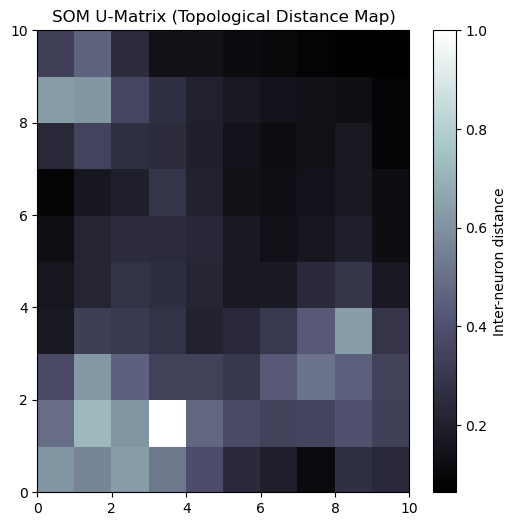

In [245]:
#Pyrcz, M.J., 2024, Applied Machine Learning in Python: A Hands-on Guide with Code [e-book]. Zenodo. doi:10.5281/zenodo.15169138
#Pyrcz, M.J., 2024, MachineLearningDemos: Python Machine Learning Demonstration Workflows Repository (0.0.3) [Software]. Zenodo. DOI: 10.5281/zenodo.13835312. GitHub repository: GeostatsGuy/MachineLearningDemos 
#e-book (Feature Ranking Chapter – Heatmaps)

#visualize the U-Matrix
plt.figure(figsize=(6,6))
from matplotlib.pylab import bone, pcolor, colorbar, plot

bone()
pcolor(som.distance_map().T)
colorbar(label='Inter-neuron distance')
plt.title("SOM U-Matrix (Topological Distance Map)")
plt.show()

### 3. Best Matching Unit (BMU) Mapping

A plot presenting the SOM grid  is generated, where each blue point represents a neuron (node). Each sample from the dataset is assigned to its **Best Matching Unit (BMU) on the grid, which is the neuron whose weight vector is most similar to the sample’s input vector in feature space.**

Because this plot shows neuron positions, it appears uniform and each dot corresponds to a SOM node. In later steps, clusters will be derived from these neurons.

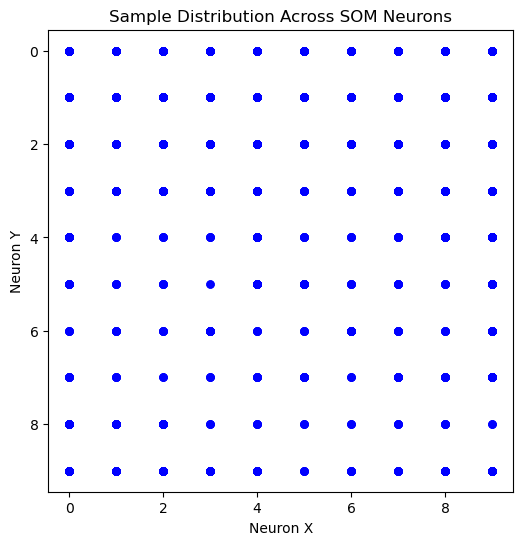

In [246]:
#ensure scaled data is float
X_scaled = X_scaled.astype(float)
X_scaled_np = X_scaled.values

#map each observation to its Best Matching Unit (BMU) 
win_map = np.array([som.winner(x) for x in X_scaled_np])
df_sub = df.iloc[:len(win_map)].copy()
df_sub['SOM_X'] = win_map[:, 0]
df_sub['SOM_Y'] = win_map[:, 1]

#plot the 2D SOM neuron positions
plt.figure(figsize=(6,6))
plt.scatter(df_sub['SOM_X'], df_sub['SOM_Y'], s=25, c='blue', alpha=0.6)
plt.gca().invert_yaxis()
plt.title("Sample Distribution Across SOM Neurons")
plt.xlabel("Neuron X")
plt.ylabel("Neuron Y")
plt.show()

### 4. Hierarchical Clustering

The trained SOM neurons are further grouped using **Agglomerative Hierarchical Clustering to identify higher level data patterns.**

Each neuron weight vector represents a learned "prototype" of similar samples, and clustering these weights merges neighboring neurons into larger and geologically meaningful zones. Each sample is then assigned the cluster label of its Best Matching Unit (BMU), resulting in three clusters of varying size.

In [247]:
#extract SOM neuron weights and cluster them
weights = som.get_weights().reshape(-1, X_scaled.shape[1])
agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
cluster_labels = agg.fit_predict(weights)

#assign cluster label to each sample based on its neuron
sample_labels = [cluster_labels[x * 10 + y] for x, y in win_map]
df_sub['Cluster'] = sample_labels

#QC
df_sub['Cluster'].value_counts()

Cluster
0    17566
1     2401
2     1697
Name: count, dtype: int64

### 5. Clusters Interpretation

This step demonstartes the relationships among the spectral GR features within each SOM derived cluster.

- **Pairplot** shows how clusters are distributed in feature space. Distinct color groupings suggest separations among lithologic facies, while overlaps indicate gradual transition zones where rock properties blend between clusters.

- **Countplot** summarizes the number of samples in each cluster, showing that some clusters are more dominant than others.

This visualization helps evaluating whether the SOM and hierarchical clustering have effectively captured natural groupings.

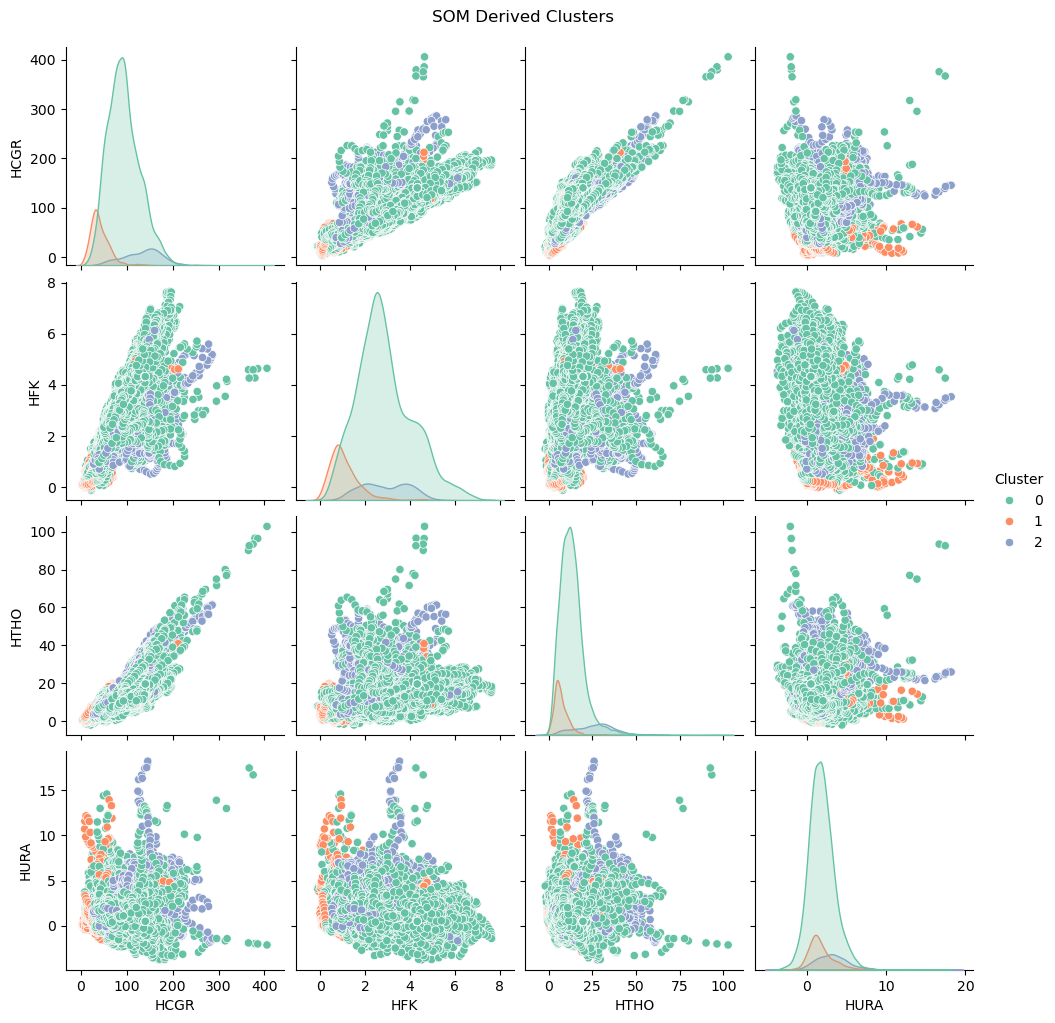

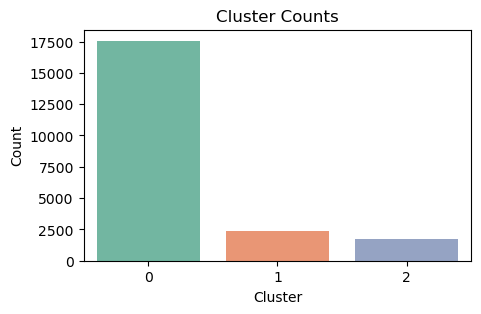

In [248]:
#Pyrcz, M.J., 2024, Applied Machine Learning in Python: A Hands-on Guide with Code [e-book]. Zenodo. doi:10.5281/zenodo.15169138 
#Pyrcz, M.J., 2024, MachineLearningDemos: Python Machine Learning Demonstration Workflows Repository (0.0.3) [Software]. Zenodo. DOI: 10.5281/zenodo.13835312. GitHub repository: GeostatsGuy/MachineLearningDemos
#e-book (Feature Ranking & Cluster Interpretation Chapters)

sns.pairplot(df_sub, vars=features, hue='Cluster', palette='Set2', diag_kind='kde')
plt.suptitle("SOM Derived Clusters", y=1.02)
plt.show()

#countplot (for frequency)
plt.figure(figsize=(5,3))
sns.countplot(x='Cluster', hue='Cluster', data=df_sub, palette='Set2', legend=False)
plt.title("Cluster Counts")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()

### 6. 2D Principle Component Analysis (PCA) Projection

To further interpret the SOM derived clusters, the dataset is projected into a 2D Principal Component Analysis (PCA) space. **PCA reduces the four spectral GR features into two orthogonal components that capture the most significant variance in the data.**

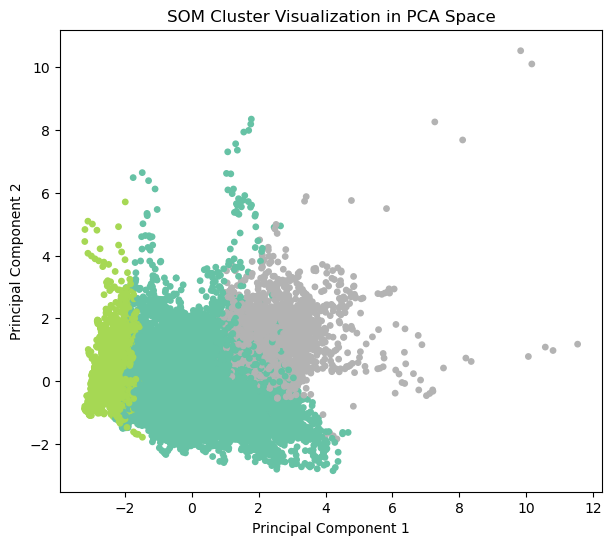

In [249]:
#Pyrcz, M.J., 2024, Applied Machine Learning in Python: A Hands-on Guide with Code [e-book]. Zenodo. doi:10.5281/zenodo.15169138
#Pyrcz, M.J., 2024, MachineLearningDemos: Python Machine Learning Demonstration Workflows Repository (0.0.3) [Software]. Zenodo. DOI: 10.5281/zenodo.13835312. GitHub repository: GeostatsGuy/MachineLearningDemos
#e-book (PCA Chapter)

pca = PCA(n_components=2)
pca_scores = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,6))
plt.scatter(pca_scores[:,0], pca_scores[:,1], c=df_sub['Cluster'], cmap='Set2', s=15)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("SOM Cluster Visualization in PCA Space")
plt.show()

### 7. Compute Internal Cluster Metrics (Silhouette Score)

**To evaluate the quality of the SOM derived clusters, the Silhouette Score is calculated. This metric measures how similar each sample is to its assigned cluster compared to other clusters, with values ranging from –1 (poor separation) to +1 (distinct clusters).**

The clustering obtained a neutral score that leans toward the positive side of Silhoutte, indicating a weak/moderate separation between clusters. This result is expected in geological data, where facies transitions are gradual and natural variability leads to overlapping feature distributions.

In [250]:
#Pyrcz, M.J., 2024, Applied Machine Learning in Python: A Hands-on Guide with Code [e-book]. Zenodo. doi:10.5281/zenodo.15169138 
#Pyrcz, M.J., 2024, MachineLearningDemos: Python Machine Learning Demonstration Workflows Repository (0.0.3) [Software]. Zenodo. DOI: 10.5281/zenodo.13835312. GitHub repository: GeostatsGuy/MachineLearningDemos
#e-book: (K-means Clustering Chapter)

score = silhouette_score(X_scaled, df_sub['Cluster'])
print(f"Silhouette Score: {score:.3f}")

Silhouette Score: 0.216


### Results
Overall, the workflow shows that unsupervised learning (SOM and hierarchical clustering) can autonomously recover latent structure and geochemical facies patterns without labels:
- Self Organizing Map (SOM) projected the 4D spectral gamma-ray features into a structured topology, preserving neighborhood relationships and reducing feature-space complexity.
- U-Matrix revealed distinct high distance boundaries, confirming nonlinear separability and presence of cluster regions.
- BMU mapping showed stable convergence and uniform neuron activation, indicating effective SOM training.
- Hierarchical clustering applied to SOM neuron weights produced three robust clusters, capturing dominant geochemical patterns.
- PCA projection showed structured grouping in 2D, indicating that the SOM derived clusters correspond to real variance.
- The Silhouette Score ~0.21 is consistent with moderate cluster separation in natural geological datasets, confirming that the model identified meaningful but overlapping geochemical regimes.

#### References
Pyrcz, M.J., 2024, Applied Machine Learning in Python: A Hands-on Guide with Code [e-book]. Zenodo. doi:10.5281/zenodo.15169138

Pyrcz, M.J., 2024, MachineLearningDemos: Python Machine Learning Demonstration Workflows Repository (0.0.3) [Software]. Zenodo. DOI: 10.5281/zenodo.13835312. GitHub repository: GeostatsGuy/MachineLearningDemos

Pyrcz, M.J., 2024, Applied Geostatistics in Python: a Hands-on Guide with GeostatsPy [e-book]. Zenodo. doi:10.5281/zenodo.15169133 

Pyrcz, M.J., 2024, GeostatsPyDemos: GeostatsPy Python Package for Spatial Data Analytics and Geostatistics Demonstration Workflows Repository (0.0.1) [Software]. Zenodo. doi:10.5281/zenodo.12667036. GitHub Repository: GeostatsGuy/GeostatsPyDemos

#### About the Supervising Professor

Michael Pyrcz is a professor in the [Cockrell School of Engineering](https://cockrell.utexas.edu/faculty-directory/alphabetical/p), and the [Jackson School of Geosciences](https://www.jsg.utexas.edu/researcher/michael_pyrcz/), at [The University of Texas at Austin](https://www.utexas.edu/), where he researches and teaches subsurface, spatial data analytics, geostatistics, and machine learning. Michael is also,

* the principal investigator of the [Energy Analytics](https://fri.cns.utexas.edu/energy-analytics) freshmen research initiative and a core faculty in the Machine Learn Laboratory in the College of Natural Sciences, The University of Texas at Austin

* an associate editor for [Computers and Geosciences](https://www.sciencedirect.com/journal/computers-and-geosciences/about/editorial-board), and a board member for [Mathematical Geosciences](https://link.springer.com/journal/11004/editorial-board), the International Association for Mathematical Geosciences. 

Michael has written over 70 [peer-reviewed publications](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en), a [Python package](https://pypi.org/project/geostatspy/) for spatial data analytics, co-authored a textbook on spatial data analytics, [Geostatistical Reservoir Modeling](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) and author of two recently released e-books, [Applied Geostatistics in Python: a Hands-on Guide with GeostatsPy](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) and [Applied Machine Learning in Python: a Hands-on Guide with Code](https://geostatsguy.github.io/MachineLearningDemos_Book/intro.html).

All of Michael’s university lectures are available on his [YouTube Channel](https://www.youtube.com/@GeostatsGuyLectures) with links to 100s of Python interactive dashboards and well-documented workflows in over 40 repositories on his [GitHub account](https://github.com/GeostatsGuy), to support any interested students and working professionals with evergreen content. To find out more about Michael’s work and shared educational resources visit his [Website](www.michaelpyrcz.com).

#### Want to Work Together?

I hope this content is helpful to those that want to learn more about subsurface modeling, data analytics and machine learning. Students and working professionals are welcome to participate.

* Want to invite me to visit your company for training, mentoring, project review, workflow design and / or consulting? I'd be happy to drop by and work with you! 

* Interested in partnering, supporting my graduate student research or my Subsurface Data Analytics and Machine Learning consortium (co-PI is Professor John Foster)? My research combines data analytics, stochastic modeling and machine learning theory with practice to develop novel methods and workflows to add value. We are solving challenging subsurface problems!

* I can be reached at mpyrcz@austin.utexas.edu.

I'm always happy to discuss,

*Michael*

Michael Pyrcz, Ph.D., P.Eng. Professor, Cockrell School of Engineering and The Jackson School of Geosciences, The University of Texas at Austin

More Resources Available at: [Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Geostatistics Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [Applied Geostats in Python e-book](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) | [Applied Machine Learning in Python e-book](https://geostatsguy.github.io/MachineLearningDemos_Book/) | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)